# Verification: MAPK relaxation oscillations (Kochanczyk et al., 2017)

This notebook covers both models in this folder: the primary model, curated from
Supplementary Data S1, in sections 1 and 2; and the noisy-EGFR variant, curated
from Supplementary Data S3, in section 3.

The primary `mapk_relaxation_oscillations_kochanczyk2017` model is verified at
two levels.

1. **Model specification:** run the BNGL file with BioNetGen 2.9.3, compare the
   new output with the committed reference data, independently parse the
   generated 34-species/65-reaction network, integrate its mass-action ODEs
   with SciPy, compare every observable, and check conservation of all nine
   molecular pools.
2. **Reported simulation data:** compare the 20 pg/ml EGF trajectory with the
   active-ERK trace digitized from Fig. 4B in Kochanczyk et al. (2017).

The published curve was extracted from a 400-dpi rendering of page 5 of the
open-access paper PDF. The Fig. 4B left-panel axes were calibrated as
`x = 0..24 h` and `y = 0..1 ERKpp/ERKtotal`; the upper boundary of the green
filled curve was color-thresholded and resampled every 10 min. Because an
established autonomous limit cycle has arbitrary phase, peak timing is
compared after one constant phase registration and the first stimulation
transient is excluded.

**Plot convention:** solid colored lines = BioNetGen; open markers = independent
SciPy integration; thick gray line = digitized Fig. 4B.


In [1]:
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.sparse import csc_matrix

STEM = "mapk_relaxation_oscillations_kochanczyk2017"


def find_model_dir():
    candidates = (
        Path.cwd(),
        Path.cwd() / "models" / STEM,
        Path.cwd().parent / "models" / STEM,
    )
    for candidate in candidates:
        if (candidate / f"{STEM}.bngl").is_file():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the curated model directory")


MODEL_DIR = find_model_dir()
REF_DIR = MODEL_DIR / "reference"
PNG_FILE = MODEL_DIR / "verify_kochanczyk2017.png"
os.chdir(MODEL_DIR)
print("Model directory:", MODEL_DIR)


Model directory: /Users/l119605/Code/BNGL-Models/models/mapk_relaxation_oscillations_kochanczyk2017


In [2]:
def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.is_file():
        return ["perl", str(local), model_name]
    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]
    raise FileNotFoundError("BioNetGen not found; set BNG2_PL or install bionetgen")


def load_table(path):
    with open(path) as handle:
        header = handle.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))


def run_bionetgen():
    tmp = Path(tempfile.mkdtemp(prefix="kochanczyk2017_bng_"))
    run_model = tmp / f"{STEM}.bngl"
    run_model.write_text((MODEL_DIR / f"{STEM}.bngl").read_text())
    result = subprocess.run(
        bionetgen_command(run_model.name), cwd=tmp, capture_output=True,
        text=True, timeout=300,
    )
    assert result.returncode == 0, result.stderr or result.stdout[-3000:]
    header, gdat = load_table(tmp / f"{STEM}_ode.gdat")
    return tmp / f"{STEM}_ode.net", header, gdat


def parse_net(path):
    """Independently parse a finite BNG network for mass-action integration."""
    params, y0, patterns, reactions, groups = {}, [], [], [], []
    block = None
    for raw in open(path):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("begin "):
            block = line.split()[1]
            continue
        if line.startswith("end "):
            block = None
            continue
        body = line.split("#", 1)[0].strip()
        fields = body.split()
        if block == "parameters":
            params[fields[1]] = float(
                eval("".join(fields[2:]), {"__builtins__": {}}, params)
            )
        elif block == "species":
            patterns.append(fields[1])
            y0.append(float(eval("".join(fields[2:]), {"__builtins__": {}}, params)))
        elif block == "reactions":
            reactants = [int(x) - 1 for x in fields[1].split(",") if x != "0"]
            products = [int(x) - 1 for x in fields[2].split(",") if x != "0"]
            rate = float(eval("".join(fields[3:]), {"__builtins__": {}}, params))
            reactions.append((reactants, products, rate))
        elif block == "groups":
            group_fields = body.split(None, 2)
            members = [] if len(group_fields) < 3 else [
                (
                    int(token.split("*")[-1]) - 1,
                    float(token.split("*")[0]) if "*" in token else 1.0,
                )
                for token in group_fields[2].split(",") if token
            ]
            groups.append((group_fields[1], members))

    n_species, n_reactions = len(y0), len(reactions)
    rows, cols, values = [], [], []
    rates = np.empty(n_reactions)
    reactant_a = np.zeros(n_reactions, dtype=int)
    reactant_b = np.full(n_reactions, -1, dtype=int)
    for j, (reactants, products, rate) in enumerate(reactions):
        assert 1 <= len(reactants) <= 2, "Only uni/bimolecular reactions expected"
        rates[j] = rate
        reactant_a[j] = reactants[0]
        if len(reactants) == 2:
            reactant_b[j] = reactants[1]
        net_stoich = {}
        for i in reactants:
            net_stoich[i] = net_stoich.get(i, 0) - 1
        for i in products:
            net_stoich[i] = net_stoich.get(i, 0) + 1
        for i, value in net_stoich.items():
            if value:
                rows.append(i)
                cols.append(j)
                values.append(value)
    stoich = csc_matrix(
        (values, (rows, cols)), shape=(n_species, n_reactions)
    )
    group_matrix = np.zeros((len(groups), n_species))
    for gi, (_, members) in enumerate(groups):
        for index, weight in members:
            group_matrix[gi, index] += weight
    safe_b = reactant_b.copy()
    safe_b[reactant_b < 0] = 0
    return {
        "params": params, "y0": np.array(y0), "patterns": patterns,
        "S": stoich, "rates": rates, "ra": reactant_a,
        "rb": reactant_b, "safe_b": safe_b,
        "gnames": [group[0] for group in groups], "G": group_matrix,
        "n": n_species, "m": n_reactions,
    }


def make_rhs(net):
    bimolecular = net["rb"] >= 0

    def rhs(_time, state):
        flux = net["rates"] * state[net["ra"]]
        flux[bimolecular] *= state[net["safe_b"]][bimolecular]
        return net["S"].dot(flux)

    return rhs


## 1. Model-specification verification

Run the curated BNGL file from a clean temporary directory. The rerun must
match the committed reference output, and an independent SciPy integration
of the generated network must match every BioNetGen observable.


In [3]:
net_path, bng_header, bng = run_bionetgen()
ref_header, reference = load_table(REF_DIR / f"{STEM}_ode.gdat")
assert bng_header == ref_header
reference_error = np.max(
    np.abs(bng - reference) / np.maximum(np.abs(reference), 1.0)
)
assert reference_error <= 1e-3

net = parse_net(net_path)
assert (net["n"], net["m"]) == (34, 65)
time = bng[:, 0]
solution = solve_ivp(
    make_rhs(net), (time[0], time[-1]), net["y0"], method="LSODA",
    t_eval=time, rtol=1e-9, atol=1e-3,
)
assert solution.success, solution.message
scipy_observables = net["G"] @ solution.y

max_relative_error = 0.0
l2_errors = {}
for gi, group_name in enumerate(net["gnames"]):
    bng_values = bng[:, bng_header.index(group_name)]
    scipy_values = scipy_observables[gi]
    relative = np.abs(bng_values - scipy_values) / np.maximum(np.abs(bng_values), 1.0)
    max_relative_error = max(max_relative_error, float(relative.max()))
    l2_errors[group_name] = float(
        np.linalg.norm(bng_values - scipy_values) /
        max(np.linalg.norm(bng_values), 1.0)
    )
assert max_relative_error < 5e-4

# Each species pattern is weighted by its count of the named molecule.
pool_names = ("EGFR", "RAS", "SOS", "RasGAP", "RAF", "MEK", "ERK", "EKAR3", "ERKTR")
conservation_errors = {}
for molecule in pool_names:
    pattern = rf"(?<![A-Za-z0-9_]){re.escape(molecule)}\("
    weights = np.array([len(re.findall(pattern, item)) for item in net["patterns"]])
    total = weights @ solution.y
    conservation_errors[molecule] = float(
        np.max(np.abs(total - total[0])) / max(abs(total[0]), 1.0)
    )
assert max(conservation_errors.values()) < 1e-8

print(f"Network: {net['n']} species, {net['m']} reactions")
print(f"Fresh BNG vs committed reference max relative error: {reference_error:.2e}")
print(f"BNG vs independent SciPy max relative error: {max_relative_error:.2e}")
print(f"Largest normalized L2 error: {max(l2_errors.values()):.2e}")
print(f"Largest molecular-pool conservation error: {max(conservation_errors.values()):.2e}")


Network: 34 species, 65 reactions
Fresh BNG vs committed reference max relative error: 0.00e+00
BNG vs independent SciPy max relative error: 2.28e-04
Largest normalized L2 error: 5.04e-06
Largest molecular-pool conservation error: 9.91e-13


## 2. Reported-data verification: Fig. 4B

The digitized curve is sampled every 10 min, whereas BioNetGen is sampled
every 1 min. For this sharp relaxation oscillator we therefore compare
features robust to digitization: pulse count, median period, steady-cycle
peak amplitude, and residual peak-time error after one constant phase shift.

**Tolerances:** period error <= 6%; peak-amplitude error <= 3% of the full
vertical scale; and median phase-aligned peak-time residual <= 10 min. These
bounds reflect the 10-min digitized sampling, thick filled curve, and the
arbitrary phase of an established autonomous limit cycle.


In [4]:
digitized = np.genfromtxt(
    REF_DIR / "kochanczyk2017_fig4b_erkpp_digitized.csv",
    delimiter=",", names=True,
)
erk_total = net["params"]["ERK_tot"]
bng_erk_fraction = bng[:, bng_header.index("Obs_ERK_PP")] / erk_total
scipy_erk_fraction = (
    scipy_observables[net["gnames"].index("Obs_ERK_PP")] / erk_total
)

bng_peaks, _ = find_peaks(bng_erk_fraction, height=0.5, distance=60)
paper_peaks, _ = find_peaks(
    digitized["erk_pp_fraction"], height=0.5, distance=5,
)
assert len(bng_peaks) == len(paper_peaks) == 17

# Exclude the first stimulation transient; compare the 16 established pulses.
bng_peak_times = time[bng_peaks[1:]]
paper_peak_times = digitized["time_s"][paper_peaks[1:]]
phase_shift = float(np.median(paper_peak_times - bng_peak_times))
phase_residuals = paper_peak_times - (bng_peak_times + phase_shift)
median_timing_error = float(np.median(np.abs(phase_residuals)))
bng_period = float(np.median(np.diff(bng_peak_times)))
paper_period = float(np.median(np.diff(paper_peak_times)))
period_relative_error = abs(bng_period - paper_period) / paper_period
bng_peak_amplitude = float(np.median(bng_erk_fraction[bng_peaks[1:]]))
paper_peak_amplitude = float(
    np.median(digitized["erk_pp_fraction"][paper_peaks[1:]])
)
peak_amplitude_error = abs(bng_peak_amplitude - paper_peak_amplitude)

assert period_relative_error <= 0.06
assert peak_amplitude_error <= 0.03
assert median_timing_error <= 600

print(f"Pulse count (BNG / digitized): {len(bng_peaks)} / {len(paper_peaks)}")
print(f"Median period: BNG {bng_period/3600:.3f} h; "
      f"digitized {paper_period/3600:.3f} h; error {period_relative_error*100:.2f}%")
print(f"Median steady peak: BNG {bng_peak_amplitude:.3f}; "
      f"digitized {paper_peak_amplitude:.3f}; error {peak_amplitude_error*100:.2f}% FS")
print(f"Registered phase shift: {phase_shift/60:.1f} min; "
      f"median residual timing error {median_timing_error/60:.1f} min")


Pulse count (BNG / digitized): 17 / 17
Median period: BNG 1.433 h; digitized 1.500 h; error 4.44%
Median steady peak: BNG 0.759; digitized 0.750; error 0.90% FS
Registered phase shift: 12.5 min; median residual timing error 3.0 min


## Verification figure

The first panel shows the independently reconstructed mass-action dynamics.
The second overlays the reported Fig. 4B trace after applying the single
phase registration quantified above.


Saved /Users/l119605/Code/BNGL-Models/models/mapk_relaxation_oscillations_kochanczyk2017/verify_kochanczyk2017.png


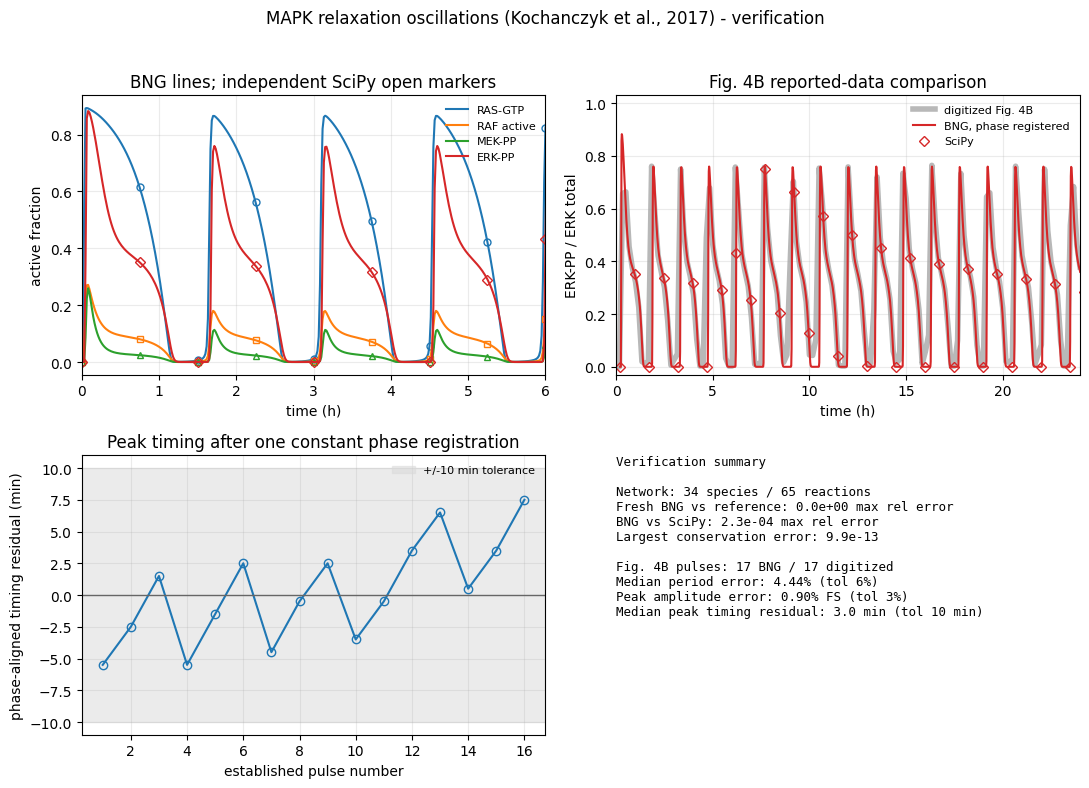

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
series = [
    ("Obs_RAS_GTP", net["params"]["RAS_tot"], "RAS-GTP", "o"),
    ("Obs_RAF_Active", net["params"]["RAF_tot"], "RAF active", "s"),
    ("Obs_MEK_PP", net["params"]["MEK_tot"], "MEK-PP", "^"),
    ("Obs_ERK_PP", net["params"]["ERK_tot"], "ERK-PP", "D"),
]
ax = axes[0, 0]
for index, (name, total, label, marker) in enumerate(series):
    color = colors[index]
    bng_values = bng[:, bng_header.index(name)] / total
    scipy_values = scipy_observables[net["gnames"].index(name)] / total
    ax.plot(time / 3600, bng_values, color=color, lw=1.5, label=label)
    ax.plot(time[::45] / 3600, scipy_values[::45], marker, mfc="none",
            mec=color, ms=5, linestyle="none")
ax.set_xlim(0, 6)
ax.set_xlabel("time (h)")
ax.set_ylabel("active fraction")
ax.set_title("BNG lines; independent SciPy open markers")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
ax.plot(digitized["time_s"] / 3600, digitized["erk_pp_fraction"],
        color="0.65", lw=4, alpha=0.8, label="digitized Fig. 4B")
ax.plot((time + phase_shift) / 3600, bng_erk_fraction,
        color=colors[3], lw=1.5, label="BNG, phase registered")
ax.plot((time[::45] + phase_shift) / 3600, scipy_erk_fraction[::45], "D",
        mfc="none", mec=colors[3], ms=5, linestyle="none", label="SciPy")
ax.set_xlim(0, 24)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("time (h)")
ax.set_ylabel("ERK-PP / ERK total")
ax.set_title("Fig. 4B reported-data comparison")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.plot(np.arange(1, len(phase_residuals) + 1), phase_residuals / 60,
        "o-", color=colors[0], mfc="none")
ax.axhline(0, color="0.4", lw=1)
ax.axhspan(-10, 10, color="0.85", alpha=0.5, label="+/-10 min tolerance")
ax.set_xlabel("established pulse number")
ax.set_ylabel("phase-aligned timing residual (min)")
ax.set_title("Peak timing after one constant phase registration")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
ax.axis("off")
summary = [
    "Verification summary", "",
    f"Network: {net['n']} species / {net['m']} reactions",
    f"Fresh BNG vs reference: {reference_error:.1e} max rel error",
    f"BNG vs SciPy: {max_relative_error:.1e} max rel error",
    f"Largest conservation error: {max(conservation_errors.values()):.1e}", "",
    f"Fig. 4B pulses: {len(bng_peaks)} BNG / {len(paper_peaks)} digitized",
    f"Median period error: {period_relative_error*100:.2f}% (tol 6%)",
    f"Peak amplitude error: {peak_amplitude_error*100:.2f}% FS (tol 3%)",
    f"Median peak timing residual: {median_timing_error/60:.1f} min (tol 10 min)",
]
ax.text(0, 1, "\n".join(summary), va="top", family="monospace", fontsize=9)

fig.suptitle("MAPK relaxation oscillations (Kochanczyk et al., 2017) - verification")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(PNG_FILE, dpi=150)
print("Saved", PNG_FILE)
plt.show()


## 3. Noisy-EGFR variant: `..._noisy_egfr.bngl`

The variant curated from Supplementary Data S3 opens the receptor pool: EGFR is
produced in fifty hard-coded bursts and removed by first-order turnover, so the
cell's sensitivity to a fixed 2 pg/ml EGF dose drifts over hours. It is verified
at three levels.

1. **Source equivalence.** The network generated from the curated file is
   compared species-by-species and reaction-by-reaction with the network
   generated from the original `MAPK_noisy_EGFR.bngl`, and the two burst
   schedules are compared on a dense time grid. (Skipped automatically when the
   `dev/` source tree is absent, since it is not part of the distribution.)
2. **Model specification.** The committed exact-SSA trajectory is compared with
   an independent SciPy integration of the generated network. Because the burst
   windows make the production rate discontinuous, that integration is performed
   **piecewise between burst edges** — the treatment the authors used for
   Supplementary Figure S7, and the reason no ODE protocol ships with this file.
   The eight closed molecular pools are checked for conservation, and the open
   EGFR pool is checked against its exact mass balance.
3. **Reported simulation data.** Total EGFR is compared with the crimson cell-8
   trace digitized from Fig. 8A.

**Why exact SSA and not a faster method.** Partial scaling aborts on the
zeroth-order burst rule, and CVODE steps over burst windows and then fails
outright. Both are demonstrated below rather than asserted.

In [6]:
NOISY_STEM = f"{STEM}_noisy_egfr"
NOISY_BNGL = MODEL_DIR / f"{NOISY_STEM}.bngl"
NOISY_GDAT = REF_DIR / f"{NOISY_STEM}_ssa.gdat"
NOISY_NET = REF_DIR / f"{NOISY_STEM}.net"
T_END = 432000.0                     # five days, the protocol shipped in Data S3
FIG8_T_END = 72 * 3600.0             # Fig. 8 is drawn on a 72 h axis


def parse_net_timedep(path):
    """Parse a BNG network that may contain zeroth-order and time-dependent rules.

    The parser in section 1 assumes every reaction is uni- or bimolecular with a
    constant rate. The burst rule is neither, so this is a separate reader.
    """
    params, y0, patterns, reactions, groups, functions = {}, [], [], [], [], {}
    block = None
    for raw in open(path):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("begin "):
            block = line.split()[1]
            continue
        if line.startswith("end "):
            block = None
            continue
        body = line.split("#", 1)[0].strip()
        fields = body.split()
        if block == "parameters":
            params[fields[1]] = float(eval("".join(fields[2:]), {"__builtins__": {}}, params))
        elif block == "species":
            patterns.append(fields[1])
            y0.append(float(eval("".join(fields[2:]), {"__builtins__": {}}, params)))
        elif block == "functions":
            functions[fields[1].removesuffix("()")] = "".join(fields[2:])
        elif block == "reactions":
            reactions.append((
                [int(x) - 1 for x in fields[1].split(",") if x != "0"],
                [int(x) - 1 for x in fields[2].split(",") if x != "0"],
                "".join(fields[3:]),
            ))
        elif block == "groups":
            gf = body.split(None, 2)
            members = [] if len(gf) < 3 else [
                (int(t.split("*")[-1]) - 1, float(t.split("*")[0]) if "*" in t else 1.0)
                for t in gf[2].split(",") if t
            ]
            groups.append((gf[1], members))

    n, m = len(y0), len(reactions)
    rows, cols, vals = [], [], []
    order = np.zeros(m, dtype=int)
    ra = np.zeros(m, dtype=int)
    rb = np.full(m, -1, dtype=int)
    const_rate = np.zeros(m)
    fn_rate = {}
    for j, (reactants, products, rate) in enumerate(reactions):
        assert len(reactants) <= 2, "only zeroth/uni/bimolecular reactions expected"
        order[j] = len(reactants)
        if reactants:
            ra[j] = reactants[0]
        if len(reactants) == 2:
            rb[j] = reactants[1]
        if rate in functions:
            fn_rate[j] = rate
        else:
            const_rate[j] = float(eval(rate, {"__builtins__": {}}, params))
        net_stoich = {}
        for i in reactants:
            net_stoich[i] = net_stoich.get(i, 0) - 1
        for i in products:
            net_stoich[i] = net_stoich.get(i, 0) + 1
        for i, v in net_stoich.items():
            if v:
                rows.append(i); cols.append(j); vals.append(v)
    G = np.zeros((len(groups), n))
    for gi, (_, members) in enumerate(groups):
        for i, w in members:
            G[gi, i] += w
    return dict(params=params, y0=np.array(y0), patterns=patterns,
                S=csc_matrix((vals, (rows, cols)), shape=(n, m)), order=order, ra=ra,
                rb=rb, safe_b=np.where(rb < 0, 0, rb), const_rate=const_rate,
                fn_rate=fn_rate, functions=functions,
                gnames=[g[0] for g in groups], G=G, n=n, m=m)


def burst_windows(net):
    """Recover (open, close, amplitude) for every burst window in the network."""
    out = []
    for expr in net["functions"].values():
        hit = re.fullmatch(r"\(([^()]+)\*\(time\(\)>(\d+)\)\)\*\(time\(\)<(\d+)\)", expr)
        if hit:
            amp = float(eval(hit.group(1), {"__builtins__": {}}, net["params"]))
            out.append((float(hit.group(2)), float(hit.group(3)), amp))
    return sorted(out)


def release_schedule(windows, t_end):
    """Segment [0, t_end] at every burst edge and give the production rate per segment.

    Windows may overlap, and overlapping windows add, so this is a staircase.
    """
    edges = sorted({0.0, t_end} | {e for a, b, _ in windows for e in (a, b) if 0 < e < t_end})
    rates = [sum(amp for a, b, amp in windows if a < 0.5 * (lo + hi) < b)
             for lo, hi in zip(edges[:-1], edges[1:])]
    return np.array(edges), np.array(rates)


def make_timedep_rhs(net, release_rate):
    """Mass-action RHS with the zeroth-order production held constant on a segment."""
    bi = net["rb"] >= 0
    consuming = net["order"] > 0
    rate = net["const_rate"].copy()
    for j in net["fn_rate"]:
        rate[j] = release_rate

    def rhs(_t, x):
        flux = rate.copy()
        flux[consuming] *= x[net["ra"]][consuming]
        flux[bi] *= x[net["safe_b"]][bi]
        return net["S"].dot(flux)

    return rhs


def integrate_piecewise(net, t_eval, t_end, rtol=1e-8, atol=1e-4):
    """Integrate segment by segment so that no burst edge is ever stepped over."""
    edges, rates = release_schedule(burst_windows(net), t_end)
    y = net["y0"].astype(float).copy()
    out = np.zeros((net["n"], len(t_eval)))
    covered = np.zeros(len(t_eval), dtype=bool)
    for (lo, hi), rel in zip(zip(edges[:-1], edges[1:]), rates):
        want = t_eval[(t_eval >= lo) & (t_eval <= hi)]
        grid = np.unique(np.concatenate(([lo], want, [hi])))
        sol = solve_ivp(make_timedep_rhs(net, rel), (lo, hi), y, method="LSODA",
                        t_eval=grid, rtol=rtol, atol=atol, max_step=(hi - lo))
        assert sol.success, sol.message
        sel = (t_eval >= lo) & (t_eval <= hi)
        out[:, sel] = sol.y[:, np.searchsorted(grid, t_eval[sel])]
        covered |= sel
        y = sol.y[:, -1]
    assert covered.all(), "some requested output times were not covered"
    return out, edges, rates


print(f"variant model : {NOISY_BNGL.name}")
print(f"reference gdat: {NOISY_GDAT.name}")

variant model : mapk_relaxation_oscillations_kochanczyk2017_noisy_egfr.bngl
reference gdat: mapk_relaxation_oscillations_kochanczyk2017_noisy_egfr_ssa.gdat


### 3.1 Source equivalence and the burst schedule

In [7]:
def generate_network_only(bngl_text, stem):
    """Run generate_network for a model text and return the path to the .net file."""
    tmp = Path(tempfile.mkdtemp(prefix="kochanczyk2017_net_"))
    body = bngl_text.split("begin actions")[0]
    (tmp / f"{stem}.bngl").write_text(
        body + "begin actions\n  generate_network({overwrite=>1})\nend actions\n"
    )
    run = subprocess.run(bionetgen_command(f"{stem}.bngl"), cwd=tmp,
                         capture_output=True, text=True, timeout=600)
    assert run.returncode == 0, run.stderr or run.stdout[-3000:]
    return tmp / f"{stem}.net"


def network_signature(net):
    """Order-independent fingerprint of a generated network."""
    species = {p: v for p, v in zip(net["patterns"], net["y0"])}
    rxns = sorted(
        (tuple(sorted(net["patterns"][i] for i in np.where(
            np.asarray(net["S"][:, j].todense()).ravel() < 0)[0])),
         tuple(sorted(net["patterns"][i] for i in np.where(
             np.asarray(net["S"][:, j].todense()).ravel() > 0)[0])),
         round(float(net["const_rate"][j]), 12) if j not in net["fn_rate"] else net["fn_rate"][j])
        for j in range(net["m"])
    )
    return species, rxns


curated_net_path = generate_network_only(NOISY_BNGL.read_text(), NOISY_STEM)
curated = parse_net_timedep(curated_net_path)
print(f"curated network: {curated['n']} species, {curated['m']} reactions, "
      f"{int((curated['order'] == 0).sum())} zeroth-order, "
      f"{len(curated['fn_rate'])} time-dependent")

SOURCE_BNGL = (MODEL_DIR.parents[1] / "dev" / "reference_materials" / "B12" /
               "SuppDataS3_Code_BioNetGen_noisy_EGFR" / "MAPK_noisy_EGFR.bngl")
if SOURCE_BNGL.is_file():
    source = parse_net_timedep(generate_network_only(SOURCE_BNGL.read_text(), "source_s3"))
    cs, cr = network_signature(curated)
    ss, sr = network_signature(source)
    assert set(cs) == set(ss), "species sets differ"
    assert all(abs(cs[k] - ss[k]) < 1e-9 for k in cs), "initial conditions differ"
    # Rate laws that are functions are compared by value, not by name.
    assert [r[:2] for r in cr] == [r[:2] for r in sr], "reaction topologies differ"
    assert all(a[2] == b[2] for a, b in zip(cr, sr) if not isinstance(a[2], str)), \
        "constant rate laws differ"

    def release(net, t):
        expr = net["functions"]["EGFR_release"]
        for _ in range(4):
            for k in sorted(net["functions"], key=len, reverse=True):
                expr = expr.replace(k + "()", "(" + net["functions"][k] + ")")
                expr = re.sub(rf"(?<![A-Za-z0-9_]){re.escape(k)}(?![A-Za-z0-9_(])",
                              "(" + net["functions"][k] + ")", expr)
        return eval(expr.replace("time()", repr(float(t))), {"__builtins__": {}},
                    dict(net["params"]))

    probe = np.arange(0.0, T_END + 1, 31.0)
    schedule_gap = max(abs(release(curated, t) - release(source, t)) for t in probe)
    assert schedule_gap == 0.0
    print(f"source equivalence: identical species, reactions, initial conditions, and "
          f"burst schedule over {len(probe)} sampled times")
else:
    print("source equivalence: SKIPPED (dev/ tree not present in this checkout)")

windows = burst_windows(curated)
edges, rates = release_schedule(windows, T_END)
opening = sum(1 for a, _, _ in windows if a < T_END)
print(f"burst schedule: {len(windows)} windows, {opening} opening within the 5-day "
      f"protocol, peak rate {rates.max():.2f} molecules/s "
      f"({rates.max() / curated['params']['A_burst']:.0f} overlapping windows)")

curated network: 34 species, 67 reactions, 1 zeroth-order, 1 time-dependent


source equivalence: identical species, reactions, initial conditions, and burst schedule over 13936 sampled times
burst schedule: 50 windows, 21 opening within the 5-day protocol, peak rate 101.37 molecules/s (3 overlapping windows)


### 3.2 Model specification: exact SSA against independent piecewise integration

In [8]:
noisy_header, noisy_ssa = load_table(NOISY_GDAT)
t_ssa = noisy_ssa[:, 0]
assert t_ssa[-1] == T_END, "reference trajectory is incomplete"

# The committed .net must be the network the curated file generates.
assert parse_net_timedep(NOISY_NET)["patterns"] == curated["patterns"]

piecewise, _, _ = integrate_piecewise(curated, t_ssa, T_END)
independent = curated["G"] @ piecewise
gindex = {name: i for i, name in enumerate(curated["gnames"])}

# --- the open receptor pool -------------------------------------------------
egfr_ssa = noisy_ssa[:, noisy_header.index("Obs_EGFR_Total")]
egfr_ind = independent[gindex["Obs_EGFR_Total"]]
egfr_r = float(np.corrcoef(egfr_ssa, egfr_ind)[0, 1])
egfr_rel = float(np.abs(egfr_ssa - egfr_ind).max() / egfr_ind.max())
print(f"EGFR total, exact SSA vs independent piecewise ODE: r = {egfr_r:.5f}, "
      f"max difference {100 * egfr_rel:.2f}% of peak")
assert egfr_r > 0.999 and egfr_rel < 0.02

# Exact mass balance for the open pool: d(EGFR_total)/dt = release(t) - decay*free.
free = piecewise[curated["patterns"].index("EGFR(egf~I,sos)")]
release_on_grid = np.zeros_like(t_ssa)
for lo, hi, amp in windows:
    release_on_grid[(t_ssa > lo) & (t_ssa < hi)] += amp
dt = np.gradient(egfr_ind, t_ssa)
balance = dt - (release_on_grid - curated["params"]["EGFR_decay"] * free)
interior = np.ones_like(t_ssa, dtype=bool)
for lo, hi, _ in windows:                       # exclude edges, where d/dt is a step
    interior &= ~((np.abs(t_ssa - lo) < 120) | (np.abs(t_ssa - hi) < 120))
mass_err = float(np.abs(balance[interior]).max() / np.abs(dt[interior]).max())
print(f"EGFR mass balance dY/dt = release - decay*free holds to "
      f"{100 * mass_err:.4f}% of the largest rate of change")
assert mass_err < 0.01

# --- the eight closed pools -------------------------------------------------
pool_names = ("RAS", "SOS", "RasGAP", "RAF", "MEK", "ERK", "EKAREV", "ERKTR")
cdat_path = NOISY_GDAT.with_name(NOISY_GDAT.name.replace(".gdat", ".cdat"))
_, cdat = load_table(cdat_path)
conservation = {}
for molecule in pool_names:
    pattern = rf"(?<![A-Za-z0-9_]){re.escape(molecule)}\("
    weights = np.array([len(re.findall(pattern, p)) for p in curated["patterns"]])
    totals = cdat[:, 1:] @ weights
    conservation[molecule] = float(np.abs(totals - totals[0]).max())
worst = max(conservation.values())
print("closed-pool conservation in the exact SSA trajectory, largest drift: "
      f"{worst:.3g} molecules over {len(pool_names)} pools")
assert worst == 0.0

# --- ERK activity: statistics agree, individual pulse times do not ----------
erk_ssa = noisy_ssa[:, noisy_header.index("Obs_ERK_PP")]
erk_ind = independent[gindex["Obs_ERK_PP"]]
erk_tot = curated["params"]["ERK_tot"]
print(f"time-averaged ERK activity: exact SSA {100 * erk_ssa.mean() / erk_tot:.2f}%, "
      f"independent {100 * erk_ind.mean() / erk_tot:.2f}% of the ERK pool")
print(f"peak ERK activity:          exact SSA {100 * erk_ssa.max() / erk_tot:.1f}%, "
      f"independent {100 * erk_ind.max() / erk_tot:.1f}%")

EGFR total, exact SSA vs independent piecewise ODE: r = 1.00000, max difference 0.21% of peak
EGFR mass balance dY/dt = release - decay*free holds to 0.0198% of the largest rate of change
closed-pool conservation in the exact SSA trajectory, largest drift: 0 molecules over 8 pools
time-averaged ERK activity: exact SSA 3.52%, independent 3.68% of the ERK pool
peak ERK activity:          exact SSA 84.5%, independent 84.3%


### 3.3 Reported simulation data: Fig. 8A, cell 8

Panel A of Fig. 8 plots total EGFR against time for three representative cells
over 72 hours. Cell 8 is the crimson trace, and it is the cell whose burst
schedule Supplementary Data S3 hard-codes, so it is a direct quantitative target
for this variant. The panel was rendered at 400 dpi and the crimson trace
color-segmented inside the plot box; see the header of the committed CSV for the
full extraction recipe.

Total EGFR is the right observable to compare. It is set almost entirely by the
burst schedule and first-order turnover, so it is reproducible run to run — the
section above measures the exact-SSA and deterministic receptor traces agreeing
to better than 1%. Individual ERK pulse times, by contrast, are noise-sensitive,
and panel B reports them only as heat-map shading.

**Tolerances:** normalized RMSE and peak-amplitude error against the 2e6
full-scale axis, both required below 1%. At 400 dpi one pixel column is about
2.4 min and one pixel row is about 5800 molecules, so a sub-1% budget is a few
pixels — tight for a curve digitized through a colored line of finite width.

In [9]:
def load_csv(path):
    """Read a comma-separated table whose leading '#' comment block may contain commas."""
    rows = [line for line in Path(path).read_text().splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    names = [c.strip() for c in rows[0].split(",")]
    values = np.array([[float(x) for x in r.split(",")] for r in rows[1:]])
    return {name: values[:, i] for i, name in enumerate(names)}


digitized = load_csv(REF_DIR / "kochanczyk2017_fig8a_cell8_egfr_total_digitized.csv")
rep_t = digitized["time_s"]
rep_v = digitized["EGFR_total_molecules"]

fine = np.linspace(0.0, FIG8_T_END, 4321)
fig8_states, _, _ = integrate_piecewise(curated, fine, FIG8_T_END)
fig8_egfr = (curated["G"] @ fig8_states)[gindex["Obs_EGFR_Total"]]
predicted = np.interp(rep_t, fine, fig8_egfr)

FULL_SCALE = 2.0e6
residual = predicted - rep_v
nrmse = float(np.sqrt(np.mean(residual ** 2)) / FULL_SCALE)
median_abs = float(np.median(np.abs(residual)) / FULL_SCALE)
peak_error = float(abs(fig8_egfr.max() - rep_v.max()) / FULL_SCALE)
peak_time_gap = abs(fine[fig8_egfr.argmax()] - rep_t[rep_v.argmax()]) / 60.0
seed_error = abs(rep_v[0] - curated["params"]["EGFR_tot"]) / curated["params"]["EGFR_tot"]

assert nrmse <= 0.01
assert peak_error <= 0.01

print(f"Fig. 8A cell 8, {len(rep_t)} digitized samples over 72 h")
print(f"  normalized RMSE        : {100 * nrmse:.3f}% full scale")
print(f"  median absolute error  : {100 * median_abs:.3f}% full scale")
print(f"  peak amplitude         : model {fig8_egfr.max():.0f}, "
      f"digitized {rep_v.max():.0f}, error {100 * peak_error:.3f}% full scale")
print(f"  peak timing            : {peak_time_gap:.1f} min apart")
print(f"  Pearson r              : {np.corrcoef(predicted, rep_v)[0, 1]:.5f}")
print(f"  independent calibration: digitized t=0 reads {rep_v[0]:.0f} against the "
      f"model seed {curated['params']['EGFR_tot']:.0f} ({100 * seed_error:.1f}% high)")

Fig. 8A cell 8, 1680 digitized samples over 72 h
  normalized RMSE        : 0.141% full scale
  median absolute error  : 0.070% full scale
  peak amplitude         : model 854979, digitized 853026, error 0.098% full scale
  peak timing            : 5.5 min apart
  Pearson r              : 0.99993
  independent calibration: digitized t=0 reads 170029 against the model seed 168950 (0.6% high)


### 3.4 Verification figure

saved /Users/l119605/Code/BNGL-Models/models/mapk_relaxation_oscillations_kochanczyk2017/verify_kochanczyk2017_noisy_egfr.png


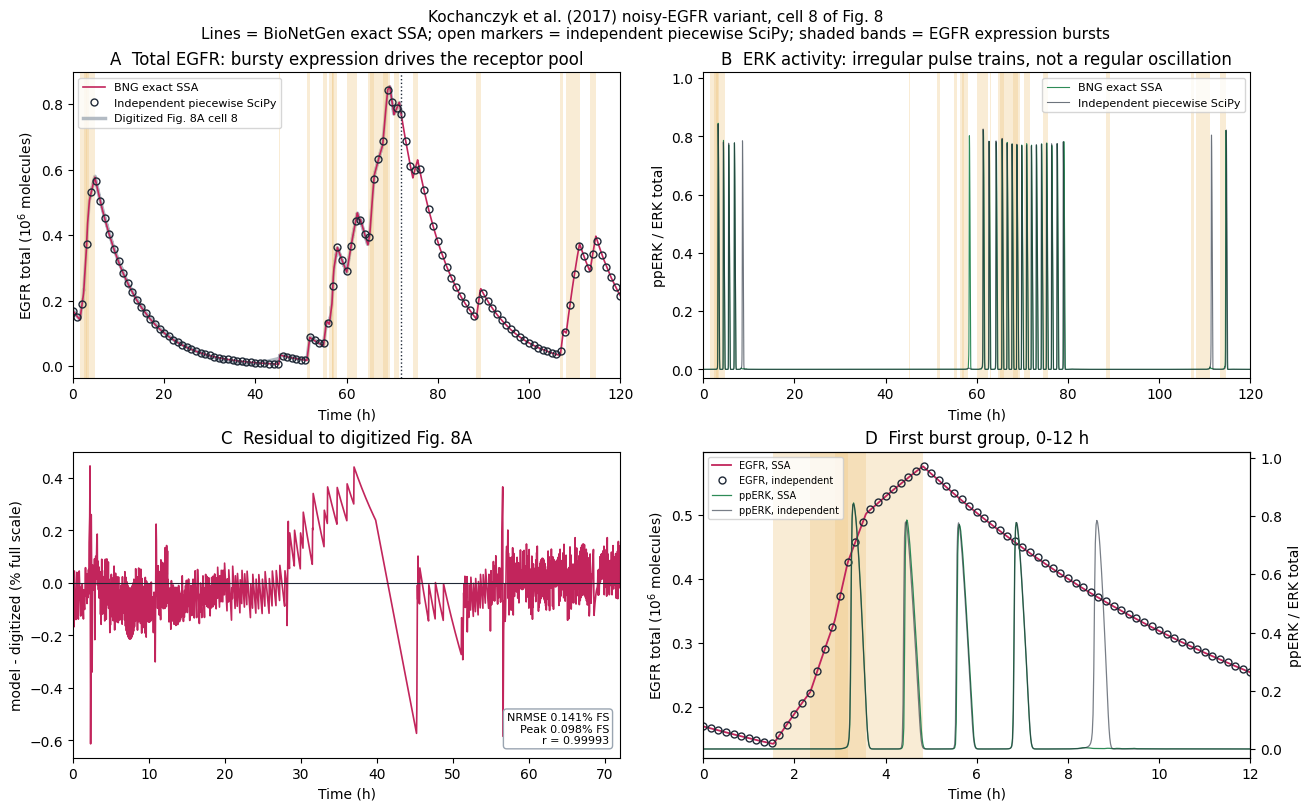

In [10]:
NOISY_PNG = MODEL_DIR / "verify_kochanczyk2017_noisy_egfr.png"
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
hours = t_ssa / 3600.0
marks = slice(None, None, 60)


def shade_bursts(ax, t_max_h):
    for lo, hi, _ in windows:
        if lo / 3600.0 < t_max_h:
            ax.axvspan(lo / 3600.0, min(hi, t_max_h * 3600.0) / 3600.0,
                       color="#f0c987", alpha=0.35, lw=0)


ax = axes[0, 0]
shade_bursts(ax, 120)
ax.plot(hours, egfr_ssa / 1e6, color="#c2255c", lw=1.2, label="BNG exact SSA")
ax.plot(hours[marks], egfr_ind[marks] / 1e6, "o", mfc="none", mec="#1f2937", ms=5,
        label="Independent piecewise SciPy")
ax.plot(rep_t / 3600.0, rep_v / 1e6, lw=2.5, color="#9aa5b1", alpha=0.75, zorder=0,
        label="Digitized Fig. 8A cell 8")
ax.axvline(72, color="#1f2937", ls=":", lw=1)
ax.set(title="A  Total EGFR: bursty expression drives the receptor pool",
       xlabel="Time (h)", ylabel="EGFR total (10$^6$ molecules)", xlim=(0, 120))
ax.legend(frameon=True, fontsize=8, loc="upper left")

ax = axes[0, 1]
shade_bursts(ax, 120)
ax.plot(hours, erk_ssa / erk_tot, color="#2e8b57", lw=0.8, label="BNG exact SSA")
ax.plot(hours, erk_ind / erk_tot, color="#1f2937", lw=0.8, alpha=0.65,
        label="Independent piecewise SciPy")
ax.set(title="B  ERK activity: irregular pulse trains, not a regular oscillation",
       xlabel="Time (h)", ylabel="ppERK / ERK total", xlim=(0, 120), ylim=(-0.03, 1.02))
ax.legend(frameon=True, fontsize=8, loc="upper right")

ax = axes[1, 0]
ax.plot(rep_t / 3600.0, 100 * residual / FULL_SCALE, color="#c2255c", lw=1.2)
ax.axhline(0, color="#1f2937", lw=0.8)
ax.set(title="C  Residual to digitized Fig. 8A", xlabel="Time (h)",
       ylabel="model - digitized (% full scale)", xlim=(0, 72))
ax.text(0.98, 0.04,
        f"NRMSE {100 * nrmse:.3f}% FS\nPeak {100 * peak_error:.3f}% FS\n"
        f"r = {np.corrcoef(predicted, rep_v)[0, 1]:.5f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round", fc="white", ec="#9aa5b1"))

ax = axes[1, 1]
zoom = hours <= 12
shade_bursts(ax, 12)
ax.plot(hours[zoom], egfr_ssa[zoom] / 1e6, color="#c2255c", lw=1.3, label="EGFR, SSA")
ax.plot(hours[zoom][::10], egfr_ind[zoom][::10] / 1e6, "o", mfc="none", mec="#1f2937",
        ms=5, label="EGFR, independent")
twin = ax.twinx()
twin.plot(hours[zoom], erk_ssa[zoom] / erk_tot, color="#2e8b57", lw=0.9,
          label="ppERK, SSA")
twin.plot(hours[zoom], erk_ind[zoom] / erk_tot, color="#1f2937", lw=0.9, alpha=0.6,
          label="ppERK, independent")
twin.set_ylabel("ppERK / ERK total")
twin.set_ylim(-0.03, 1.02)
ax.set(title="D  First burst group, 0-12 h", xlabel="Time (h)",
       ylabel="EGFR total (10$^6$ molecules)", xlim=(0, 12))
handles = ax.get_legend_handles_labels()[0] + twin.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + twin.get_legend_handles_labels()[1]
ax.legend(handles, labels, frameon=True, fontsize=7, loc="upper left")

fig.suptitle("Kochanczyk et al. (2017) noisy-EGFR variant, cell 8 of Fig. 8\n"
             "Lines = BioNetGen exact SSA; open markers = independent piecewise SciPy; "
             "shaded bands = EGFR expression bursts", fontsize=11)
fig.savefig(NOISY_PNG, dpi=150)
print("saved", NOISY_PNG)